<span STYLE="font-size:150%"> 
    Segment microCT scans
</span>

Docker image: gnasello/slicer-env:2023-07-06 \
Latest update: 10 March 2023

- load image stack in Slicer
- segment mineralized tissue
- compute segmented statistics (volumes)

# Load libraries

In [1]:
import pyslicer as ps
import slicer
from pathlib import Path
import pandas as pd

# Volume input

## Load `.nrrd` file into 3D Slicer

Write the path of the `.nrrd` file and load it to Slicer

In [2]:
# this cell is tagged 'parameters'
volume_file = 'microCT_volume/microCT_volume.nrrd'
output_dir_path = 'segmented_volumes'
segments_greyvalues_file = 'segmented_volumes/segments_greyvalues.csv'
segmentMask_inclusion_file = 'segmented_volumes/ROI.seg.nrrd'
segmentMask_exclusion_file = 'microCT_calibration/spheres_calibration.seg.nrrd'

In [4]:
path = Path(volume_file)

# Remove image numbering _0000, _0001 ...
filename_output = path.stem[:-4]

In [5]:
masterVolumeNode = slicer.util.loadNodeFromFile(volume_file)

Print spacing

In [6]:
## mm
masterVolumeNode.GetSpacing()

(0.01799928, 0.01799928, 0.01799928)

Make ```segmented_volumes``` folder

In [7]:
output_directory = Path(output_dir_path)

output_directory.mkdir(parents=True, exist_ok=True)

In [8]:
# Monitor Memory in Slicer
import psutil, os
print(psutil.Process(os.getpid()).memory_info().rss / (1024**3), "GB used")

1.0075950622558594 GB used


GB used

# Create segmentationNode

## Create segmentation-related nodes

Create segmentation node

In [9]:
segmentationNode = ps.segmentation.segmentationNode(name='Segmentation')

Create temporary segment editor to get access to effects

In [10]:
segmentEditorWidget, segmentEditorNode = ps.segmentation.segmentEditorWidget(segmentationNode = segmentationNode, 
                                                                             masterVolumeNode = masterVolumeNode)

## Load Segment Mask

In [11]:
def createInclusionSegment(labelmapNode, segmentationNode):
    """
    Convert a labelmap to a segment named InclusionMask.
    """
    segmentation_logic = slicer.modules.segmentations.logic()
    segmentation_logic.ImportLabelmapToSegmentationNode(labelmapNode, segmentationNode)

    segmentation = segmentationNode.GetSegmentation()
    segment = segmentation.GetNthSegment(segmentation.GetNumberOfSegments() - 1)
    segment.SetName("InclusionMask")

    return segmentation.GetSegmentIdBySegmentName("InclusionMask")

In [12]:
inclusion_id = None
try:
    inclusion_labelmap = slicer.util.loadNodeFromFile(
        segmentMask_inclusion_file,
        'VolumeFile',
        properties={'labelmap': True}
    )
    print("Inclusion mask file loaded")

    inclusion_id = createInclusionSegment(inclusion_labelmap, segmentationNode)
    slicer.mrmlScene.RemoveNode(inclusion_labelmap)

    print("Inclusion mask converted into a segment")

except Exception as e:
    print("Inclusion mask could not be loaded")
    print("Reason:", e)

Inclusion mask could not be loaded
Reason: Failed to load node from file: segmented_volumes/ROI.seg.nrrd
Error: Loading segmented_volumes/ROI.seg.nrrd -  load failed.



In [13]:
#
# Exclusion segmentation load and processing
#

exclusion_id = None

try:
    exclusion_file_path = Path(segmentMask_exclusion_file)

    # Load the external segmentation
    segmentationNode_exclusion = slicer.util.loadSegmentation(
        exclusion_file_path.resolve(),
        properties={'name': "Segmentation-Exclusion"}
    )
    print("Exclusion segmentation loaded")

    # Create a segment editor for this temporary segmentation
    segmentEditorWidget_exclusion, segmentEditorNode_exclusion = ps.segmentation.segmentEditorWidget(
        segmentationNode=segmentationNode_exclusion,
        masterVolumeNode=masterVolumeNode
    )

    # Grow all visible segments by N pixels
    grow_pixels = 10
    ps.segmentation.margin_segmentation(
        segmentationNode_exclusion,
        masterVolumeNode,
        segmentEditorNode_exclusion,
        segmentEditorWidget_exclusion,
        margin_pixels=grow_pixels,
        apply_to_all_visible=True
    )
    print("All exclusion segments grown by", grow_pixels, "pixels")
   
    combined_id = ps.segmentation.merge_all_segments_into_one(segmentationNode_exclusion,
                                                              segmentEditorWidget_exclusion,
                                                              segmentEditorNode_exclusion,
                                                              merged_name="CombinedExclusion"
                                                             )

    #
    # Import the combined exclusion segment into the main segmentationNode
    #

    # Export the merged result as a labelmap
    export_labelmap = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLLabelMapVolumeNode")
    slicer.modules.segmentations.logic().ExportSegmentsToLabelmapNode(
        segmentationNode_exclusion,
        [combined_id],
        export_labelmap,
        masterVolumeNode
    )

    # Import into the main segmentation
    slicer.modules.segmentations.logic().ImportLabelmapToSegmentationNode(
        export_labelmap,
        segmentationNode
    )

    # The imported segment becomes the last one in the main segmentation
    main_seg = segmentationNode.GetSegmentation()
    new_segment = main_seg.GetNthSegment(main_seg.GetNumberOfSegments() - 1)
    new_segment.SetName("ExclusionMask")
    exclusion_id = main_seg.GetSegmentIdBySegmentName("ExclusionMask")

    print("Combined exclusion mask imported into main segmentation")

    # Remove temporary nodes
    slicer.mrmlScene.RemoveNode(export_labelmap)
    slicer.mrmlScene.RemoveNode(segmentationNode_exclusion)

except Exception as e:
    print("Exclusion mask processing failed")
    print("Reason:", e)

Exclusion segmentation loaded
All exclusion segments grown by 10 pixels
Combined exclusion mask imported into main segmentation


In [14]:

# Compute and apply the final mask
try:
    final_mask_id = ps.segmentation.compute_and_apply_final_mask(
                                                                inclusion_id=inclusion_id,
                                                                exclusion_id=exclusion_id,
                                                                mainSegmentationNode=segmentationNode,
                                                                segmentEditorWidget=segmentEditorWidget,
                                                                segmentEditorNode=segmentEditorNode,
                                                                masterVolumeNode=masterVolumeNode
                                                            )
    
    if final_mask_id:
        print("Final mask applied. Segmentation will be restricted to SegmentMask.")
    else:
        print("No masks found. Editing allowed everywhere.")
except Exception as e:
    print("Final mask computation failed")
    print("Reason:", e)


Final mask applied. Segmentation will be restricted to SegmentMask.


# Thresholding

## Read file with thresholding values

In [15]:
grey_df = pd.read_csv(segments_greyvalues_file)

segments_greyvalues = grey_df.to_dict('list')
segments_greyvalues

{'Bone': [23103.33814450368, 65535.0]}

Calibration threshold: 23103.33814450368


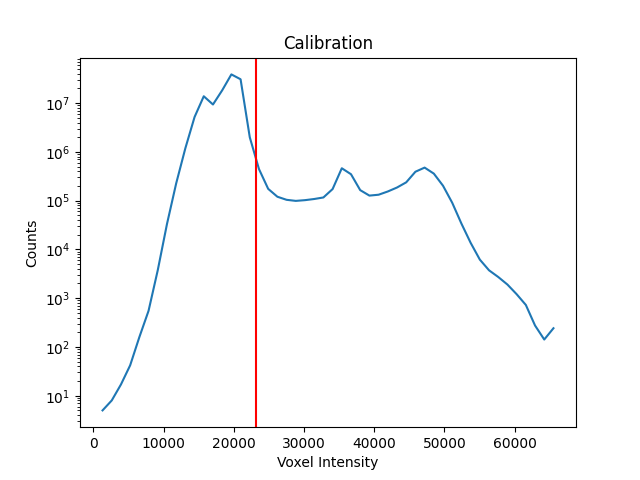

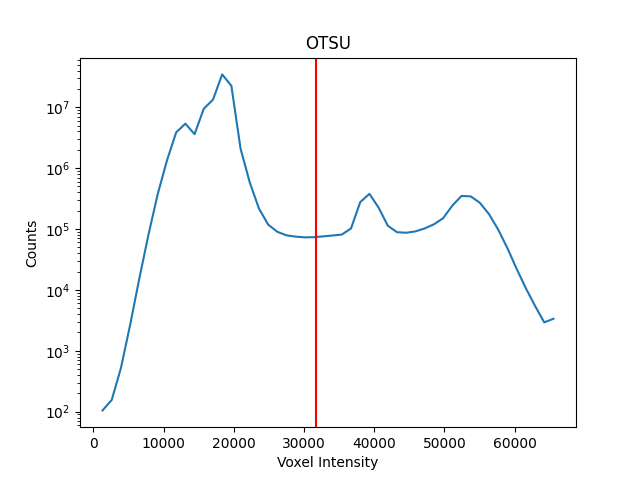

In [16]:
method = 'Calibration'

threshold = segments_greyvalues['Bone'][0]

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = 'Calibration', yscale='log')

## Create segments by thresholding

In [17]:
ps.segmentation.segments_by_thresholding(segments_greyvalues, 
                                         segmentationNode,
                                         segmentEditorNode,
                                         segmentEditorWidget)

Set segments color

In [18]:
segments_color = {
    "Bone": (0.9450980392156862, 0.8392156862745098, 0.5686274509803921), # "Bone" color in Slicer
    }

segments_color

{'Bone': (0.9450980392156862, 0.8392156862745098, 0.5686274509803921)}

In [19]:
ps.segmentation.set_segments_color(segments_color, segmentationNode)

In [20]:
# Monitor Memory in Slicer
import psutil, os
print(psutil.Process(os.getpid()).memory_info().rss / (1024**3), "GB used")

3.2722854614257812 GB used


GB used

# Operation on segments

## Manual fix of the segmentation

Sometimes it might be necessary to remove speckles at the image boundaries. If so, use the `scissor` tool in the `Segment Editor` before proceeding with the rest of the script. 

## Remove small islands

REMOVE_SMALL_ISLANDS operation from the [SegmentEditorIslandsEffect](https://github.com/Slicer/Slicer/blob/294ef47edbac2ccb194d5ee982a493696795cdc0/Modules/Loadable/Segmentations/EditorEffects/Python/SegmentEditorIslandsEffect.py#L402)

In [21]:
segment_name = 'Bone'
minimum_size = 30 #number of voxels

In [22]:
ps.segmentation.remove_small_islands(minimum_size, 
                                     segment_name, 
                                     segmentEditorNode,
                                     segmentEditorWidget)

## Smoothing thresholded segment

In [23]:
segment_name = 'Bone'
gaussiaSD_mm = 0.001 #units are in millimiters

In [24]:
ps.segmentation.gaussian_smoothing(gaussiaSD_mm, 
                                   segment_name, 
                                   segmentEditorNode, 
                                   segmentEditorWidget)

# Export segments

## As seg.nrrd file (labelmap node)

Export a selection of segments (identified by their names), from [slicer tutorial](https://slicer.readthedocs.io/en/latest/developer_guide/script_repository.html#export-labelmap-node-from-segmentation-node)

Bone LabelmapNode

In [25]:
seg_name = 'Bone'

In [26]:
mineralized_labelmap = ps.segmentation.individual_segment_to_labelmapNode(segmentName = seg_name,
                                                                          segmentationNode = segmentationNode,
                                                                          volumeNode = masterVolumeNode)

In [27]:
filename_output = seg_name + '.seg.nrrd'

slicer.util.exportNode(mineralized_labelmap, output_directory / filename_output)

True